# Notebook 13.4: Market-Cap Rotation with a Canary Signal

`B37124_13_04_hybrid_asset_allocation.ipynb`

# Rotating Across Market Caps with a Canary Signal

Most of the strategies in this chapter generate a signal and trade it. This one adds a layer that sits in front of the trade: a *regime filter* that decides whether you should be in the market at all before it decides what to buy. The device that makes that decision is called a canary, and learning to build and, more importantly, to *evaluate* one is the real lesson here.

The strategy comes from Richman (2026), who applies the Hybrid Asset Allocation (HAA) framework of Keller and Keuning (2016, 2023) to U.S. equity market-cap segments. The mechanics are simple and rules-based:

- On the last trading day of each month, compute a momentum score for an inflation-protected Treasury ETF (TIP). This is the canary.
- If the canary score is non-positive, the market regime is judged unfavorable: hold short-term Treasuries (SHY) for the next month and own no equities.
- If the canary score is positive, the regime is favorable: hold 100% of the single equity segment (large cap SPY, mid cap MDY, or small cap IJR) with the strongest momentum for the next month.

The momentum score is the 13612 composite: the unweighted average of the trailing 1-, 3-, 6-, and 12-month total returns. We use it both for the canary and for picking the winning equity segment.

The reason to study this strategy is not the rotation. It is the canary. A regime filter is a binary classifier dressed up as a trading rule, and the central mistake practitioners make is trusting it because the backtest looks good, without ever asking whether the signal itself is any good. So before we backtest anything, we are going to put the canary on trial on its own: build a confusion matrix, read its precision and recall, measure what it actually earns when it is right versus what it costs when it is wrong, and watch how it behaves in every major crisis of the sample. Only then do we run the full strategy, and we run it twice, with and without the canary, to confirm at the portfolio level what the signal-level test already told us.

In this chapter, we will cover the following topics:

- Building the 13612 composite momentum signal and auditing it for lookahead bias
- Turning a canary asset into a monthly regime decision
- Evaluating a regime signal in isolation: confusion matrix, classification report, conditional payoff, and crisis behavior
- Diagnosing whipsaw and signal persistence
- Implementing the winner-take-all market-cap rotation and backtesting it against a total-market benchmark
- Measuring what the canary contributes by comparing the strategy with and without it

## Setting up the environment and configuration

Before anything else, the notebook prepares its own environment. It pulls the two helper modules and the package list from the book's repository, so nothing has to be uploaded into the session by hand.

Package versions live in one file in the repository rather than being written into each notebook. When a pinned version stops resolving, and eventually it will, the fix is a single commit instead of an edit to every notebook in the chapter.

This cell also sets where price data comes from. The `USE_SAVED_PRICES` flag controls it:

- `True`, the default, reads prices from files stored in the repository. Every figure printed in this chapter came from those exact files, so your results will match the book.
- `False` downloads fresh data from Yahoo Finance. The notebook still runs end to end, but your numbers will differ from the printed ones.

The reason for the saved files is worth stating. Yahoo recomputes its entire adjusted price history whenever a new dividend or split is recorded, so a series downloaded today is not the series downloaded last month, and across a twenty-year window those revisions compound. Without fixed data, a reader whose numbers differ has no way to tell whether the cause is data drift at the source or a mistake in their own setup.

In [21]:
# --- Environment and data source -------------------------------------------
# Fetches the helper modules and the package list from the book repository,
# installs, and reports what actually landed. Nothing needs uploading by hand.

import os, sys, subprocess, importlib

# True  : read prices from the saved files, results match the book
# False : download fresh from Yahoo, results will differ
USE_SAVED_PRICES = True

REPO_RAW = ('https://raw.githubusercontent.com/PacktPublishing/'
            'Hands-on-Financial-Trading-with-Python-Second-Edition/main')
SCRIPTS_URL = f'{REPO_RAW}/FINAL/python_scripts'
DATA_URL    = f'{REPO_RAW}/FINAL/chapter13/data_files'
REQS_URL    = f'{REPO_RAW}/FINAL'

# Versions this chapter was written against. Used only for the report below.
TESTED = {'python': '3.13', 'numpy': '2.1.3', 'pandas': '2.2.3',
          'vectorbt': '0.28.5', 'pyarrow': '18.1.0', 'yfinance': '0.2.66'}


def fetch(fname, url_base):
    """Download a file into the session if it is not already there."""
    if os.path.exists(fname):
        print(f'  using local {fname}')
        return fname
    subprocess.run(['wget', '-q', f'{url_base}/{fname}'])
    if not os.path.exists(fname):
        raise FileNotFoundError(f'Could not fetch {fname} from {url_base}')
    print(f'  fetched {fname}')
    return fname


def fetch_data_file(fname):
    """Return a local path to a saved data file, downloading it once if needed."""
    return fetch(fname, DATA_URL)


# A pinned package with no wheel for your Python does not fail cleanly: pip
# tries to build from source and the runtime usually dies first. Checking here
# turns that into a readable message.
PY = f'{sys.version_info.major}.{sys.version_info.minor}'
if PY != TESTED['python']:
    print(f'NOTE: this chapter was tested on Python {TESTED["python"]}; you are on {PY}.')
    print('      If the install below hangs, a pinned package has no wheel for '
          'your Python.\n')

fetch('requirements-ch13.txt', REQS_URL)
fetch('functions.py', SCRIPTS_URL)
fetch('vectorbt_harness.py', SCRIPTS_URL)

# No -q here. A silent install that fails leaves you debugging an ImportError
# several cells later instead of reading the actual error now.
print('\nInstalling...')
!pip install -r requirements-ch13.txt 2>&1 | tail -6

print(f'\n{"package":<12}{"installed":<14}{"tested":<12}')
print('-' * 38)
print(f'{"python":<12}{PY + "." + str(sys.version_info.micro):<14}{TESTED["python"]:<12}')
for pkg in ['numpy', 'pandas', 'pyarrow', 'vectorbt', 'numba', 'yfinance']:
    try:
        v = importlib.import_module(pkg).__version__
    except Exception:
        v = 'not installed'
    flag = '' if TESTED.get(pkg) in (None, v) else '  <- differs'
    print(f'{pkg:<12}{v:<14}{TESTED.get(pkg, "-"):<12}{flag}')

print(f'\nUSE_SAVED_PRICES = {USE_SAVED_PRICES}'
      f'  ({"saved files, results match the book" if USE_SAVED_PRICES else "live download, results will differ"})')

  using local requirements-ch13.txt
  using local functions.py
  using local vectorbt_harness.py

Installing...

package     installed     tested      
--------------------------------------
python      3.13.15       3.13        
numpy       2.1.3         2.1.3       
pandas      2.2.3         2.2.3       
pyarrow     18.1.0        18.1.0      
vectorbt    0.28.5        0.28.5      
numba       0.61.2        -           
yfinance    0.2.66        0.2.66      

USE_SAVED_PRICES = True  (saved files, results match the book)


In [22]:
import warnings

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

warnings.simplefilter(action='ignore', category=FutureWarning)
plt.rcParams['figure.figsize'] = (12, 6)

# ── Universe ──────────────────────────────────────────────────────────
# The offensive sleeve: the three equity segments we rotate among.
OFFENSIVE_TICKERS = ['SPY', 'MDY', 'IJR']   # large / mid / small cap
CANARY_TICKER     = 'TIP'                    # regime filter (not traded)
DEFENSIVE_TICKER  = 'SHY'                    # safe haven when regime is off Note: you could try SHV for pure cash
BENCHMARK_TICKER  = 'VTI'                    # total U.S. market (not traded)

# Tickers we need prices for, and the subset that can hold weight.
ALL_TICKERS    = OFFENSIVE_TICKERS + [CANARY_TICKER, DEFENSIVE_TICKER, BENCHMARK_TICKER]
WEIGHT_TICKERS = OFFENSIVE_TICKERS + [DEFENSIVE_TICKER]

# ── Signal parameters ─────────────────────────────────────────────────
# 13612: average of trailing 1, 3, 6, 12 month returns. The 12 month
# lookback sets the warmup, so the first usable signal needs 12 months
# of prior history.
LOOKBACKS    = [1, 3, 6, 12]
MAX_LOOKBACK = max(LOOKBACKS)

# ── Date range ────────────────────────────────────────────────────────
# Start early enough that after the 12 month warmup the first signal
# lands near the paper's Jan 2005 inception. IJR and MDY both trade well
# before 2004 on yfinance, so the binding constraint is the warmup.
DATA_START = '2003-06-01'
DATA_END   = '2026-05-31'

# Where the sparse weights file gets written for the harness.
WEIGHTS_FILE = 'haa_mktcap_rotation_weights.csv'

print('Configuration loaded.')
print(f'Offensive (rotated):  {OFFENSIVE_TICKERS}')
print(f'Canary (watched):     {CANARY_TICKER}')
print(f'Defensive (haven):    {DEFENSIVE_TICKER}')
print(f'Benchmark (compared): {BENCHMARK_TICKER}')
print(f'Sample request:       {DATA_START} to {DATA_END}')

Configuration loaded.
Offensive (rotated):  ['SPY', 'MDY', 'IJR']
Canary (watched):     TIP
Defensive (haven):    SHY
Benchmark (compared): VTI
Sample request:       2003-06-01 to 2026-05-31


## 1.0 Downloading the price data

We load dividend-adjusted daily closes for every ticker, from the saved file or from a live yfinance download depending on the flag set earlier. The saved file holds the same frame yfinance returns, so everything downstream of this cell is identical either way. The adjusted close folds in dividends and splits, which matters here: the canary is an income-paying bond ETF and the defensive sleeve is Treasuries, so a price-only series would understate their returns and distort the momentum signal.

All six tickers arrive together, including VTI even though we never trade it, because we need it later as both the benchmark and the ground-truth outcome when we put the canary on trial. We then drop any rows where a ticker is missing, so every date in the frame has a price for all six. The first valid date per ticker tells us which one binds the start of our usable history.

In [23]:
# yfinance returns a column MultiIndex (field, ticker) for multiple tickers.
# We want the adjusted close, which under auto_adjust=True lives in 'Close'.
if USE_SAVED_PRICES:
    raw = pd.read_parquet(fetch_data_file('ch13_nb04_signal_prices.parquet'))
else:
    raw = yf.download(ALL_TICKERS, start=DATA_START, end=DATA_END, auto_adjust=True)
daily_prices = raw['Close'].copy()

# Keep only dates where every ticker has a price, so the universe is
# aligned and momentum scores are comparable across assets.
daily_prices = daily_prices[ALL_TICKERS].sort_index().dropna()

print(f'Daily prices shape: {daily_prices.shape}')
print(f'Date range: {daily_prices.index[0].date()} to {daily_prices.index[-1].date()}')
print('\nFirst valid date per ticker (before the dropna alignment):')
print(raw['Close'][ALL_TICKERS].apply(lambda s: s.first_valid_index().date()))
print('\nFirst 3 aligned rows:')
print(daily_prices.head(3))

  fetched ch13_nb04_signal_prices.parquet
Daily prices shape: (5655, 6)
Date range: 2003-12-05 to 2026-05-29

First valid date per ticker (before the dropna alignment):
Ticker
SPY    2003-06-02
MDY    2003-06-02
IJR    2003-06-02
TIP    2003-12-05
SHY    2003-06-02
VTI    2003-06-02
dtype: object

First 3 aligned rows:
Ticker            SPY        MDY        IJR        TIP        SHY        VTI
Date                                                                        
2003-12-05  70.411499  78.352707  16.211460  49.330029  52.997635  34.201336
2003-12-08  70.885979  78.952492  16.328323  49.286381  52.939644  34.484303
2003-12-09  70.339035  77.806038  16.092115  49.160500  52.907463  34.121414


The download gives us 5,655 aligned trading days from December 5, 2003 to May 29, 2026, six columns wide. The per-ticker first-valid dates show why the aligned history starts when it does: five of the six ETFs trade back to June 2003, but TIP, our canary, only lists on December 5, 2003. Because we require every ticker to have a price on every date, TIP sets the start of the usable sample. This is fine for us: the 12-month momentum warmup pushes the first signal to roughly December 2004 and the first traded month to January 2005, which lines up with the paper's inception date. The youngest asset in a multi-asset strategy always governs how far back you can test, and it is worth knowing which one that is before you build anything on top of it.

The strategy decides once a month, on the last trading day, and holds for the following month. So we collapse the daily series to one price per calendar month: the close on the final trading day of that month.

We do this with a groupby on the year-month period rather than a plain `resample('ME')`, for one practical reason. A `resample('ME')` stamps each row with the calendar month-end date (for example, 2008-09-30), which may be a weekend or holiday on which nothing traded. The groupby-and-last approach keeps the actual last trading date (2008-09-30 if it traded, 2008-09-29 if the 30th was a holiday), so every date in our monthly index is a real date on which a price existed and a trade could have happened. This keeps the signal dates honest and makes the later lookahead audit exact.

In [24]:
# Group by calendar year-month, take the last row in each group. That row
# is the last actual trading day of the month, so its index date is real
# (never a weekend or holiday).
monthly_prices = daily_prices.groupby(daily_prices.index.to_period('M')).last()

# The index is now a PeriodIndex (e.g. 2008-09). Replace it with the real
# last-trading-date captured from the daily index, so downstream lookback
# math and audits work on actual dates.
last_dates = daily_prices.groupby(daily_prices.index.to_period('M')).apply(
    lambda g: g.index[-1]
)
monthly_prices.index = last_dates.values
monthly_prices.index.name = 'date'

print(f'Monthly prices shape: {monthly_prices.shape}')
print(f'First 3 month-end dates: {[d.date() for d in monthly_prices.index[:3]]}')
print(f'Last 3 month-end dates:  {[d.date() for d in monthly_prices.index[-3:]]}')
print('\nFirst 3 rows:')
print(monthly_prices.head(3))

Monthly prices shape: (270, 6)
First 3 month-end dates: [datetime.date(2003, 12, 31), datetime.date(2004, 1, 30), datetime.date(2004, 2, 27)]
Last 3 month-end dates:  [datetime.date(2026, 3, 31), datetime.date(2026, 4, 30), datetime.date(2026, 5, 29)]

First 3 rows:
Ticker            SPY        MDY        IJR        TIP        SHY        VTI
date                                                                        
2003-12-31  73.677277  80.204559  16.689951  49.318947  53.412064  35.593182
2004-01-30  75.133865  81.954727  17.184422  49.920242  53.476860  36.522625
2004-02-27  76.153465  83.933205  17.498285  50.991833  53.735664  37.034134


We now have 270 month-end observations, one price per ticker per calendar month, running from December 31, 2003 to May 29, 2026. Notice that the last printed month-end is May 29, not May 31: the 31st fell on a weekend, so the last actual trading day was the 29th. That is exactly what the groupby-and-last approach buys us. Had we used a plain calendar resample, the index would read 2026-05-31, a date on which no price exists, and any later attempt to line up a signal date with a real trade would be off by a day or more. With real trading dates locked in, we can compute the momentum signal and audit it against the calendar with confidence.

## 2.0 Building the 13612 composite momentum signal

The 13612 composite is the engine behind both decisions in this strategy: whether the canary says risk-on or risk-off, and which equity segment to hold when it does. The name encodes the recipe. For each asset we compute the trailing total return over four windows, 1, 3, 6, and 12 months, then take their unweighted average. A single number that blends a fast read of the last month with a slow read of the last year.

Why blend horizons at all? A one-month return is responsive but noisy, easily whipsawed by a single bad week. A twelve-month return is stable but slow, still pointing up well after a trend has broken. Averaging the four spreads the bet across speeds, so no single horizon dominates the call. Keller and Keuning popularized this exact 1-3-6-12 blend in their momentum work, and Richman carries it over unchanged.

The one thing we must get right is direction. The momentum at month t can only use prices up to and including month t. We compute each trailing return as the current price divided by the price N months earlier, using `.shift(N)`, which moves older prices forward onto the current row. That guarantees row t never sees a future price. We will state this audit explicitly in the code and check it again later with a manual spot-check.

In [25]:
# Trailing total return for each lookback window.
# monthly_prices.shift(lb) moves the price from lb months ago onto the
# current row, so (price_t / price_{t-lb} - 1) uses only past data.
# No future price ever touches row t: no lookahead.
momentum_components = {
    lb: monthly_prices / monthly_prices.shift(lb) - 1.0
    for lb in LOOKBACKS
}

# 13612 composite = unweighted mean of the four trailing returns.
composite_momentum = sum(momentum_components.values()) / len(LOOKBACKS)

first_valid = composite_momentum.dropna().index[0]
print(f'Composite momentum shape: {composite_momentum.shape}')
print(f'First valid row (needs {MAX_LOOKBACK}m history): {first_valid.date()}')
print('\nComposite scores, last 3 months:')
print(composite_momentum[ALL_TICKERS].tail(3))

Composite momentum shape: (270, 6)
First valid row (needs 12m history): 2004-12-31

Composite scores, last 3 months:
Ticker           SPY       MDY       IJR       TIP       SHY       VTI
date                                                                  
2026-03-31  0.016153  0.045770  0.063418  0.005496  0.011893  0.018574
2026-04-30  0.129233  0.138834  0.185739  0.017412  0.011541  0.130761
2026-05-29  0.142465  0.114033  0.142616  0.014562  0.010064  0.142415


The first valid composite lands on December 31, 2004, exactly one year after our December 2003 start, because the 12-month leg of the blend needs a full year of prior prices. Every row before that is NaN and will drop out when we assign weights.

The tail gives a feel for the numbers. At the end of May 2026 the canary, TIP, scores 0.0146, a positive composite, so the regime is favorable and the strategy would hold equities into June. Among the three equity segments, SPY and IJR are nearly tied at the top (0.1425 and 0.1426) with MDY a step behind, so the winner-take-all rule would put 100% into IJR by the narrowest of margins. This is worth pausing on: when the top scores are this close, a winner-take-all rule can swing the entire portfolio from one segment to another on a rounding-error difference in momentum. We will see the practical cost of that sensitivity when we look at turnover and whipsaw later. For now, the signal is built and audited for direction. Next we turn the canary's single number into a monthly regime call.

### 2.1 Turning the canary into a regime decision

The canary's job is binary: risk-on or risk-off. The rule is absolute momentum on TIP. If TIP's 13612 composite is positive, the regime is offensive and the strategy will hold equities next month. If it is non-positive (zero or negative), the regime is defensive and the strategy retreats to SHY.

The economic reasoning is what makes this a canary rather than an arbitrary filter. TIP is inflation-protected Treasury debt. Its price reflects both real rates and inflation expectations, and it tends to weaken when the market is repricing liquidity and inflation risk, the same forces that precede or accompany equity stress. So a falling TIP is a read on the macro environment, not on equities directly, which is the point: the canary is a separate instrument watched for what it says about the weather, not a thing we trade. This is the difference between a regime filter with a thesis and a moving-average rule slapped on the asset you already hold.

A note on the boundary. We treat a composite of exactly zero as defensive, matching the paper's non-positive rule. Ties on a continuous signal are vanishingly rare, but the convention should be stated rather than left to chance.

In [26]:
# Regime from the canary's absolute momentum.
# 1 = offensive (TIP composite > 0): hold equities next month.
# 0 = defensive (TIP composite <= 0): hold SHY next month.
regime = (composite_momentum[CANARY_TICKER] > 0).astype(int)

# Preserve the warmup as missing rather than mislabeling it as defensive:
# months without a full 12m history have no real signal.
regime[composite_momentum[CANARY_TICKER].isna()] = np.nan

valid_regime = regime.dropna()
print(f'Valid regime months: {len(valid_regime)}')
print(f'Offensive: {int(valid_regime.sum())} '
      f'({valid_regime.mean():.1%})')
print(f'Defensive: {int((valid_regime == 0).sum())} '
      f'({1 - valid_regime.mean():.1%})')

# Show the first ten regime switches so we can see it reacting to events.
switches = valid_regime[valid_regime.diff().ne(0) & valid_regime.notna()]
print('\nFirst 10 regime states / switches:')
for d, v in switches.head(10).items():
    print(f'  {d.date()}  ->  {"Offensive" if v == 1 else "Defensive"}')

Valid regime months: 258
Offensive: 196 (76.0%)
Defensive: 62 (24.0%)

First 10 regime states / switches:
  2004-12-31  ->  Offensive
  2006-03-31  ->  Defensive
  2006-07-31  ->  Offensive
  2006-12-29  ->  Defensive
  2007-01-31  ->  Offensive
  2008-09-30  ->  Defensive
  2008-12-31  ->  Offensive
  2009-01-30  ->  Defensive
  2009-03-31  ->  Offensive
  2013-05-31  ->  Defensive


The canary spends 196 of 258 months offensive (76%) and 62 months defensive (24%). That split is what we would hope for from a regime filter: it stays risk-on roughly three-quarters of the time, stepping aside only occasionally. A canary that went defensive half the time would be too trigger-happy to compound; one that almost never did would offer no protection.

The switch dates already hint at both the value and the flaws we are about to measure. The flip to defensive on September 30, 2008 is the canary working as designed, going risk-off as the Global Financial Crisis broke. But look at the December 2008 to March 2009 stretch: offensive, defensive, offensive in consecutive months. That is whipsaw, the signal flickering during the most violent part of the crisis, and each flip is a round-trip trade with real cost. The early-2006 and late-2006 flips are smaller versions of the same thing. So the canary clearly reacts to stress, but it does not react cleanly, and a list of switch dates cannot tell us whether the reactions were worth it. To answer that, we have to stop looking at the signal in isolation and start asking what equities actually did in the months the canary made each call. That is the job of the next section.

## 3.0 Putting the canary on trial: the confusion matrix

Here is the central idea of this notebook. A regime filter is a binary classifier. Every month it makes a prediction, risk-on or risk-off, and every month the market delivers an outcome, a good equity month or a bad one. That means we can evaluate the canary the way we would evaluate any classifier, with a confusion matrix, before we let it touch a dollar of capital. Most people skip this. They wire the signal into a backtest, see a nice equity curve, and conclude the signal is good. But a good backtest can hide a mediocre signal that got lucky in a few months, and a mediocre backtest can hide a good signal undone by costs. Testing the signal on its own separates the quality of the prediction from everything else.

A classifier needs labels, and choosing the label is itself a modeling decision. The canary is trying to keep us out of bad equity months, so the honest label is the realized next-month return of the broad market, VTI, the same asset we benchmark against. We define a month as bad if VTI's total return that month was negative. The canary's prediction for that month was made one month earlier: a defensive call is a prediction that the coming month will be bad.

The alignment is the part to get right. The regime decided at the end of month t governs month t+1. So we must compare the regime at t against VTI's return in t+1, which means shifting one of the two series by a month. Line them up wrong and every number in this section is meaningless, so we build the aligned frame carefully and show a few rows before computing anything.

In [27]:
# Next-month VTI total return: the outcome the canary is trying to predict.
vti_monthly_ret = monthly_prices[BENCHMARK_TICKER].pct_change()

# Align the regime decision at month t with the return it governs, t+1.
# regime is dated to the signal month; shift the *return* back by one month
# so each row pairs a decision with the month it actually controls.
eval_df = pd.DataFrame({
    'regime': regime,                              # decision at month t
    'next_ret': vti_monthly_ret.shift(-1),         # VTI return in month t+1
}).dropna()

# Ground truth and prediction, both as binary labels.
# actual_bad   = 1 if next month's VTI return was negative
# pred_defensive = 1 if the canary went defensive (predicting a bad month)
eval_df['actual_bad'] = (eval_df['next_ret'] < 0).astype(int)
eval_df['pred_defensive'] = (eval_df['regime'] == 0).astype(int)

print('Aligned evaluation frame (first 5 rows):')
print(eval_df.head())
print(f'\nMonths evaluated: {len(eval_df)}')
print(f'Bad months (VTI < 0): {eval_df["actual_bad"].sum()} '
      f'({eval_df["actual_bad"].mean():.1%})')
print(f'Defensive calls: {eval_df["pred_defensive"].sum()} '
      f'({eval_df["pred_defensive"].mean():.1%})')

# Confusion matrix: rows = actual, cols = predicted.
# Labels ordered [0, 1] = [good month / offensive, bad month / defensive].
cm = confusion_matrix(eval_df['actual_bad'], eval_df['pred_defensive'])
print('\nConfusion matrix (rows = actual, cols = predicted):')
print(pd.DataFrame(
    cm,
    index=['Actual: good month', 'Actual: bad month'],
    columns=['Pred: offensive', 'Pred: defensive'],
))

Aligned evaluation frame (first 5 rows):
            regime  next_ret  actual_bad  pred_defensive
date                                                    
2004-12-31     1.0 -0.024989           1               0
2005-01-31     1.0  0.020851           0               0
2005-02-28     1.0 -0.018720           1               0
2005-03-31     1.0 -0.022027           1               0
2005-04-29     1.0  0.038814           0               0

Months evaluated: 257
Bad months (VTI < 0): 86 (33.5%)
Defensive calls: 62 (24.1%)

Confusion matrix (rows = actual, cols = predicted):
                    Pred: offensive  Pred: defensive
Actual: good month              137               34
Actual: bad month                58               28


The aligned frame confirms the timing: the December 2004 decision (offensive) is paired with January 2005's return, and so on down the column. With that verified, the numbers are sobering. Of 257 evaluated months, 86 were bad (VTI negative, 33.5%), and the canary made 62 defensive calls (24.1%).

Read the confusion matrix as a classifier and the canary looks weak:

- It went defensive on 28 of the 86 bad months. That is the saves, but it caught less than a third of the bad months.
- It missed 58 bad months, staying offensive and walking straight into them. That is the large bottom-left cell, and it is the error that hurts.
- Of its 62 defensive calls, 34 landed on months that turned out fine. More than half its defensive calls were, in hindsight, false alarms that cost upside.

If you stopped here, you would throw this signal away. It catches few bad months and cries wolf more often than not. And that is precisely the lesson: a confusion matrix on raw month counts treats every month as equally important, but they are not. A canary built for tail protection does not need to catch every down month or even most of them. It needs to catch the catastrophic ones, the months where being in the market costs you 10 or 15%, while the down months it misses are mild. Counting months hides that asymmetry completely. To see whether this canary is actually worth its place, we have to stop counting months and start weighing them by what they cost.

### 3.1 Reading precision, recall, and why accuracy misleads

The confusion matrix holds four numbers; precision, recall, and F1 are just ways of reading them that make the canary's behavior easier to compare and harder to fool yourself about. We focus on the defensive call, since that is the prediction with consequences (an offensive call is just "stay invested").

- Precision of the defensive call answers: when the canary cried wolf, how often was there a wolf? It is the saves divided by all defensive calls. Low precision means a lot of false alarms, each one a month you sat in cash while the market rose.
- Recall of the defensive call answers: of all the bad months, how many did the canary catch? It is the saves divided by all bad months. Low recall means most bad months slipped past.
- F1 is the harmonic mean of the two, a single summary that punishes a signal for being lopsided.

The reason we do not lead with accuracy is that accuracy is the number most people reach for and the one most likely to deceive. Watch what it does here. Then notice that even precision and recall, useful as they are, still treat a 1% down month and a 15% crash as the same event. They count outcomes; they do not weigh them. That blind spot is the bridge to the next cell, where we finally weigh the months in the only unit that matters: money.

In [28]:
# Full classification report. Class 1 = defensive call / bad month,
# which is the prediction we care about.
report = classification_report(
    eval_df['actual_bad'],
    eval_df['pred_defensive'],
    target_names=['offensive / good month', 'defensive / bad month'],
    digits=3,
)
print(report)

# Pull out the headline numbers for the defensive call explicitly.
tn, fp, fn, tp = confusion_matrix(
    eval_df['actual_bad'], eval_df['pred_defensive']
).ravel()

precision_def = tp / (tp + fp) if (tp + fp) else 0.0
recall_def = tp / (tp + fn) if (tp + fn) else 0.0
accuracy = (tp + tn) / len(eval_df)

# The "always offensive" strawman: never go defensive at all.
# Its accuracy is just the share of good months.
always_off_acc = 1 - eval_df['actual_bad'].mean()

print(f'Defensive-call precision: {precision_def:.3f}  '
      f'(when it went defensive, this share of months were truly bad)')
print(f'Defensive-call recall:    {recall_def:.3f}  '
      f'(of all bad months, this share were caught)')
print(f'\nCanary accuracy:          {accuracy:.3f}')
print(f'"Always offensive" acc.:  {always_off_acc:.3f}  '
      f'(a signal that never warns at all)')

                        precision    recall  f1-score   support

offensive / good month      0.703     0.801     0.749       171
 defensive / bad month      0.452     0.326     0.378        86

              accuracy                          0.642       257
             macro avg      0.577     0.563     0.564       257
          weighted avg      0.619     0.642     0.625       257

Defensive-call precision: 0.452  (when it went defensive, this share of months were truly bad)
Defensive-call recall:    0.326  (of all bad months, this share were caught)

Canary accuracy:          0.642
"Always offensive" acc.:  0.665  (a signal that never warns at all)


Look at the bottom two lines first, because they contain the whole lesson of this cell. The canary's accuracy is 0.642. A signal that never goes defensive at all, that simply predicts "good month" every single month, scores 0.665. By accuracy, the do-nothing strawman wins. If accuracy were our decision rule, we would conclude the canary is actively worse than useless and delete it.

That verdict is wrong, and accuracy is why. With two-thirds of months positive, a classifier is rewarded for always guessing the majority class. Accuracy on imbalanced outcomes measures how well you can predict the obvious, not how well you handle the cases that matter. This is the single most common way practitioners fool themselves when evaluating a regime filter.

Precision and recall on the defensive call tell a more useful but still discouraging story. Precision is 0.452: fewer than half the canary's defensive calls landed on genuinely bad months, so most of the time it goes to cash, it is leaving money on the table. Recall is 0.326: it catches only about a third of all bad months. An F1 of 0.378 confirms the signal is both imprecise and incomplete as a month-by-month predictor.

So every classification metric we have, accuracy, precision, recall, F1, says this is a poor signal. And yet the strategy built on it cuts the benchmark's drawdown by more than half. How can a bad classifier produce a good strategy? Because all four of these metrics count months as if they were interchangeable, and they are not. The next cell weighs them by what they actually cost, and the picture inverts.

### 3.2 Weighing the months: what the canary earns when right and costs when wrong

Every classification metric so far has counted months as equal. They are not. A canary built for tail protection lives or dies on asymmetry: the bad months it catches must be worse, on average, than the good months it sits out. If the crashes it avoids are violent and the rallies it misses are mild, the signal can be wrong most of the time and still add enormous value. This is the cell where we finally measure that, in the only unit that matters.

We return to the four cells of the confusion matrix, but instead of counting months in each, we average VTI's actual next-month return in each. That turns the matrix into a payoff table:

- When the canary went defensive and the month was bad (the saves): how deep was the loss it dodged?
- When the canary went defensive and the month was good (false alarms): how much upside did it forgo?
- When the canary stayed offensive and the month was bad (the misses): how bad were the hits it took?
- When the canary stayed offensive and the month was good: ordinary participation.

Then we put a single number on the whole thing. The canary's defensive calls move us out of equities and into roughly flat cash, so the value added by a defensive call is approximately the loss avoided: the negative of VTI's return that month. Averaged across all defensive calls, and scaled by how often it goes defensive, that is the per-month edge the canary contributes, decomposed into what it saves on real crashes versus what it gives back on false alarms.

In [29]:
# Average next-month VTI return in each confusion-matrix cell.
def cell_stats(df, pred_def, actual_bad):
    mask = (df['pred_defensive'] == pred_def) & (df['actual_bad'] == actual_bad)
    rets = df.loc[mask, 'next_ret']
    return len(rets), rets.mean()

cells = {
    'Defensive + bad month (saves)':     cell_stats(eval_df, 1, 1),
    'Defensive + good month (false alarm)': cell_stats(eval_df, 1, 0),
    'Offensive + bad month (misses)':    cell_stats(eval_df, 0, 1),
    'Offensive + good month (participation)': cell_stats(eval_df, 0, 0),
}

print('Average next-month VTI return by confusion-matrix cell:')
print(f'{"Cell":<42}{"N":>5}{"Avg VTI ret":>14}')
for label, (n, avg) in cells.items():
    print(f'{label:<42}{n:>5}{avg:>13.2%}')

# Compare the two outcomes that drive the asymmetry directly.
saves_n, saves_avg = cells['Defensive + bad month (saves)']
miss_n, miss_avg = cells['Offensive + bad month (misses)']
fa_n, fa_avg = cells['Defensive + good month (false alarm)']

print(f'\nBad months CAUGHT (defensive): avg {saves_avg:.2%} over {saves_n} months')
print(f'Bad months MISSED (offensive): avg {miss_avg:.2%} over {miss_n} months')
print(f'False alarms (defensive, good): avg +{fa_avg:.2%} forgone over {fa_n} months')

# Per-month edge from going defensive, approximating cash as ~0% return.
# Value added on a defensive month ~= loss avoided = -next_ret.
defensive = eval_df[eval_df['pred_defensive'] == 1]
avg_avoided = (-defensive['next_ret']).mean()
share_defensive = eval_df['pred_defensive'].mean()
edge_per_month = avg_avoided * share_defensive

print(f'\nAcross all {len(defensive)} defensive calls:')
print(f'  Avg return avoided per defensive month: {avg_avoided:.2%}')
print(f'  Share of months defensive:              {share_defensive:.1%}')
print(f'  Approx. edge contributed per month:     {edge_per_month:.3%}')

Average next-month VTI return by confusion-matrix cell:
Cell                                          N   Avg VTI ret
Defensive + bad month (saves)                28       -4.81%
Defensive + good month (false alarm)         34        3.83%
Offensive + bad month (misses)               58       -3.36%
Offensive + good month (participation)      137        3.27%

Bad months CAUGHT (defensive): avg -4.81% over 28 months
Bad months MISSED (offensive): avg -3.36% over 58 months
False alarms (defensive, good): avg +3.83% forgone over 34 months

Across all 62 defensive calls:
  Avg return avoided per defensive month: 0.07%
  Share of months defensive:              24.1%
  Approx. edge contributed per month:     0.018%


The payoff table sharpens the picture, and it does not hand us a clean victory. Read the asymmetry first. The bad months the canary caught averaged −4.81%, while the bad months it missed averaged −3.36%, so the signal does lean the right way: the crashes it pulled us out of were deeper than the ones it walked into. That is the tail-protection asymmetry working, and it is the reason a signal this imprecise can still be useful.

The magnitude, however, is humbling. Across all 62 defensive calls the average return avoided was just +0.07% per month, because the 28 real saves at −4.81% each are very nearly cancelled by the 34 false alarms that gave back +3.83% of upside each. Scaled by how often the canary goes defensive, the approximate edge it contributes works out to +0.018% per month, which over 21 years of compounding is not nothing but is far smaller than the strategy's headline drawdown reduction would lead you to expect. The honest read is that on average, month in and month out, the canary barely breaks even on its defensive calls.

So where does the strategy's real value come from? It comes from the extremes rather than the average month. A −4.81% average across the saves hides the fact that a handful of those months were far worse than −4.81%, and avoiding a single −15% month matters enormously even when you pay for it with several +3.83% false alarms along the way. Averages flatten exactly the tail events a canary exists to handle, which is why the per-month edge looks trivial while the drawdown protection is dramatic: the value is concentrated in a few crisis months, not spread evenly across all of them. That is precisely the hypothesis the next cell tests, by walking through every major crisis in the sample one at a time instead of averaging them away.

### 3.3 Where the value lives: the canary through every major crisis

The per-month average told us the canary roughly breaks even on a typical defensive call, so if the signal earns its keep, it has to do so in the handful of months when being out of equities was worth a great deal. This cell tests that directly by walking through the major stress windows of the sample one at a time, rather than blending them into a single number. For each window we ask three plain questions: how many of those months did the canary spend defensive, what did VTI do over the window, and did stepping aside actually help.

We look at six episodes that every reader will recognize: the 2008 Global Financial Crisis, the 2011 debt-ceiling and euro-zone selloff, the 2015 to early 2016 oil and China growth scare, the late-2018 rate-hike correction, the 2020 COVID crash, and the 2022 inflation bear market. These are the moments a tail-protection signal is built for, and they are also where its failures show up most clearly. We will not hide the failures: the 2020 episode in particular is going to show the canary at its worst, and that honest result is more instructive than any of the wins.

In [30]:
# Named crisis windows (inclusive month-end ranges).
crisis_windows = {
    '2008 GFC':              ('2008-01-01', '2009-06-30'),
    '2011 debt ceiling/euro':('2011-05-01', '2011-12-31'),
    '2015-16 oil/China':     ('2015-07-01', '2016-02-29'),
    '2018 Q4 rate selloff':  ('2018-10-01', '2018-12-31'),
    '2020 COVID':            ('2020-02-01', '2020-04-30'),
    '2022 inflation bear':   ('2022-01-01', '2022-12-31'),
}

# Every return below is VTI's next-month return. The canary holds ~flat cash
# when defensive, so "VTI avoided" is the loss it dodged by sitting out and
# "VTI captured" is what it earned by staying invested.
rows = []
for name, (start, end) in crisis_windows.items():
    window = eval_df.loc[start:end]
    if window.empty:
        continue
    n_months = len(window)
    n_defensive = int(window['pred_defensive'].sum())
    vti_cum = (1 + window['next_ret']).prod() - 1
    sat_out = window.loc[window['pred_defensive'] == 1, 'next_ret']
    stayed_in = window.loc[window['pred_defensive'] == 0, 'next_ret']
    rows.append({
        'Crisis': name,
        'Window months': n_months,
        'Months defensive': f'{n_defensive}/{n_months}',
        'VTI buy&hold (window)': f'{vti_cum:.1%}',
        'Avg VTI on months OUT': f'{sat_out.mean():.2%}' if len(sat_out) else '—',
        'Avg VTI on months IN': f'{stayed_in.mean():.2%}' if len(stayed_in) else '—',
    })

crisis_table = pd.DataFrame(rows).set_index('Crisis')
print(crisis_table.to_string())

                        Window months Months defensive VTI buy&hold (window) Avg VTI on months OUT Avg VTI on months IN
Crisis                                                                                                                 
2008 GFC                           18             5/18                -24.3%                -5.20%                0.27%
2011 debt ceiling/euro              8              0/8                 -1.9%                     —               -0.09%
2015-16 oil/China                   8              7/8                 -2.2%                -1.19%                7.11%
2018 Q4 rate selloff                3              3/3                  0.6%                 0.46%                    —
2020 COVID                          3              0/3                  2.7%                     —                1.55%
2022 inflation bear                12            11/12                 -8.4%                -0.85%                3.26%


This table shows the canary winning, losing, and getting whipsawed in the same six rows, and it makes no sense without first stating what I expect from a monthly regime-switching strategy. A signal that decides once a month and holds for a month is built for orderly declines: recessions and bear markets that unfold over quarters, where trailing momentum has time to roll over, go defensive, and stay defensive while the damage plays out. It cannot be expected to handle a crash and recovery that both happen inside a single rebalance cycle. Judging this kind of strategy on V-shaped events is judging it on the situations it was never designed to win.

The two wins are real, and they are the orderly, multi-quarter declines this strategy is built for:

- **2008 GFC:** defensive 5 of 18 months, sitting out an average of −5.20% per month while staying-in months averaged +0.27%. It missed none of the recoveries and stepped aside for the worst of a long grinding bear.
- **2022 inflation bear:** defensive 11 of 12 months against a benchmark that lost 8.4% over the year. The cleanest result in the table.

The two apparent failures were both V-shaped, sharp drops followed almost immediately by sharp recoveries:

- **2015-16 oil/China:** defensive 7 of 8 months, sat out only −1.19% on average, and nearly missed a +7.11% snapback month.
- **2020 COVID:** defensive 0 of 3 months. TIP momentum was still positive going into the crash, so it did not dodge the February-to-March collapse, and the +2.7% window figure hides a violent intra-period drawdown that monthly data cannot see.

Here is where I want to defend the strategy rather than apologize for it. Those two failures are the same failure, and it is structural, not a flaw in the signal. A monthly momentum filter reacts to a fast reversal only in time to watch the reversal happen: by the time trailing returns roll over enough to flip the regime, the bottom is in and the rebound is underway, so the strategy sells low and buys back high. No parameter tuning fixes this, because it is a property of the sampling frequency, not the threshold. This is the normal, expected behavior of monthly regime-switching momentum, and anyone who shows you a monthly strategy that sailed cleanly through both the COVID crash and its recovery is showing you a fit, not a strategy (or did incredibly well and given them credit).

So I do not read this table as four wins and two losses. I read it as the strategy doing its job in the two environments it is built for, the slow bears of 2008 and 2022, and behaving as a monthly system must in the two it cannot help, the V-shapes of 2015-16 and 2020. That distinction tells you when to trust the strategy and when not to be surprised it struggled. Averaging all six episodes into one number would have erased the lesson, which is why the event study, not the confusion matrix, tells you what a regime signal is really worth.

And this is also why I am showing you this process. This will provide you the framework and questions to ask whenever you build a strategy that has a signal overlay.

### 3.4 Diagnosing whipsaw: how persistent is the signal?

The crisis walk-through kept surfacing whipsaw: the canary flickering between offensive and defensive in 2015-16, and the rapid-fire flips around the GFC we noticed back when we first listed the regime switches. A signal that changes its mind every month is expensive regardless of how accurate it is, because every change of state is a round-trip trade that pays spread and slippage. So the last thing we check before trusting the canary is persistence: when it makes a call, does it stick with it long enough for the call to pay off, or does it thrash?

We measure this two ways. First, the count of regime switches across the whole sample and the implied average spell length, which tells us how often the signal commits versus reconsiders. Second, the distribution of spell lengths, separating the durable stretches from the one-month round-trips. A single isolated defensive month is the worst case: we pay to exit and pay to re-enter, often capturing nothing in between. The more of those we see, the more the signal's theoretical edge will be eaten by trading frictions, which is the gap between the clean signal-level story and the backtest with costs included that we run later.

The crisis walk-through kept surfacing whipsaw: the canary flickering between offensive and defensive in 2015-16, and the rapid-fire flips around the GFC we noticed back when we first listed the regime switches. A signal that changes its mind every month is expensive regardless of how accurate it is, because every change of state is a round-trip trade that pays spread and slippage. So the last thing we check before trusting the canary is persistence: when it makes a call, does it stick with it long enough for the call to pay off, or does it thrash?

We measure this two ways. First, the count of regime switches across the whole sample and the implied average spell length, which tells us how often the signal commits versus reconsiders. Second, the distribution of spell lengths, separating the durable stretches from the one-month round-trips. A single isolated defensive month is the worst case: we pay to exit and pay to re-enter, often capturing nothing in between. The more of those we see, the more the signal's theoretical edge will be eaten by trading frictions, which is the gap between the clean signal-level story and the costed backtest we run later.

In [31]:
# Work on the valid (post-warmup) regime series, in order.
r = valid_regime.astype(int)

# A switch is any month whose state differs from the prior month.
switches = int((r.diff().fillna(0) != 0).sum())

# Spell lengths: run-length encode the consecutive identical states.
spells = []
current_state = r.iloc[0]
length = 1
for s in r.iloc[1:]:
    if s == current_state:
        length += 1
    else:
        spells.append((current_state, length))
        current_state = s
        length = 1
spells.append((current_state, length))

spell_df = pd.DataFrame(spells, columns=['state', 'months'])
off_spells = spell_df[spell_df['state'] == 1]['months']
def_spells = spell_df[spell_df['state'] == 0]['months']

print(f'Total months:            {len(r)}')
print(f'Regime switches:         {switches}')
print(f'Avg months per spell:    {len(r) / len(spells):.1f}')
print(f'Number of distinct spells: {len(spells)}')

print(f'\nOffensive spells: {len(off_spells)}  '
      f'(avg {off_spells.mean():.1f} months, longest {off_spells.max()})')
print(f'Defensive spells: {len(def_spells)}  '
      f'(avg {def_spells.mean():.1f} months, longest {def_spells.max()})')

# One-month round-trips: the costliest case, in and straight back out.
one_month_def = int((def_spells == 1).sum())
one_month_off = int((off_spells == 1).sum())
print(f'\nOne-month defensive spells (exit and immediately re-enter): {one_month_def}')
print(f'One-month offensive spells (re-enter and immediately exit):  {one_month_off}')
print(f'Defensive spell length distribution:\n{def_spells.value_counts().sort_index()}')

Total months:            258
Regime switches:         34
Avg months per spell:    7.4
Number of distinct spells: 35

Offensive spells: 18  (avg 10.9 months, longest 50)
Defensive spells: 17  (avg 3.6 months, longest 12)

One-month defensive spells (exit and immediately re-enter): 8
One-month offensive spells (re-enter and immediately exit):  4
Defensive spell length distribution:
months
1     8
2     2
3     1
4     2
6     1
9     1
12    2
Name: count, dtype: int64


The persistence numbers are better than the crisis whipsaw made me fear, but they carry a clear warning. Across 258 months the canary switched regime 34 times, for an average spell of 7.4 months, so on the whole it commits to a call rather than thrashing. The asymmetry between the two states is telling and sensible: offensive spells average 10.9 months and run as long as 50, because bull markets are long and the signal rightly stays invested through them, while defensive spells average just 3.6 months, because the signal is meant to step aside briefly and return, not to sit in cash for years.

The warning is in the defensive spell distribution. Of the 17 defensive spells, 8 lasted exactly one month: the signal exited equities and re-entered the very next month. Those one-month round-trips are the most expensive thing a regime filter can do, because each one pays to get out and pays to get back in, and from the conditional-payoff cell we know the average defensive call barely broke even before any trading frictions at all. Eight such round-trips, plus four one-month offensive spells doing the mirror image, are the concrete mechanism behind the gap we are about to see: a signal whose edge looks fine in clean monthly returns but gives much of it back once spread and slippage are charged on every one of these flips. Note however, that all it takes is for the indicator to correctly call a major bear market to erase all of the whipsaws.

This is the bridge from the signal-level analysis to the portfolio. Everything in section 3 evaluated the canary as a pure predictor, with no money changing hands. We found a signal that is a poor month-by-month classifier, leans the right way on the size of the losses it avoids, earns its keep almost entirely in slow bear markets, is structurally blind to V-shaped crashes, and flips to cash for a single month often enough to worry about trading frictions. Now we build the actual weights and run the strategy through the backtest harness to see what all of that is worth in dollars, with costs applied, and then we strip the canary out entirely to confirm how much of the result it was responsible for.

## 4.0 Building the weights and writing the sparse file

Now we turn the regime decision into actual portfolio weights. The rule is winner-take-all: in an offensive month, 100% goes to the single equity segment (SPY, MDY, or IJR) with the highest 13612 score; in a defensive month, 100% goes to SHY. The portfolio holds exactly one instrument at a time, which keeps the logic transparent and makes the canary's effect easy to see in the holdings timeline later.

Two implementation points matter here. First, we drop the warmup. Every month before December 2004 has a NaN composite score and therefore no valid decision, so those rows fall out and the weights file begins on the first real signal. Second, we write the weights in the sparse format the backtest harness expects: one row per decision date, the four tradeable tickers as columns, and the target weight as a decimal. The harness reads each row as a rebalance instruction, holds the position until the next dated row, and pairs each weight column with the matching price column by name. We never forward-fill the weights ourselves; the sparse rows are the complete instruction set, and the harness handles the holding in between.

In [32]:
# Winner-take-all weights, one instrument per month.
weights = pd.DataFrame(0.0, index=composite_momentum.index, columns=WEIGHT_TICKERS)
equity_scores = composite_momentum[OFFENSIVE_TICKERS]

for date in weights.index:
    tip_score = composite_momentum.loc[date, CANARY_TICKER]

    # Warmup or any missing score: mark the whole row NaN so it drops out.
    if pd.isna(tip_score):
        weights.loc[date] = np.nan
        continue

    if regime.loc[date] == 0:
        # Defensive: all to the safe haven.
        weights.loc[date, DEFENSIVE_TICKER] = 1.0
    else:
        # Offensive: all to the strongest equity segment.
        scores = equity_scores.loc[date]
        if scores.isna().any():
            weights.loc[date] = np.nan
            continue
        weights.loc[date, scores.idxmax()] = 1.0

# Drop the warmup and any incomplete rows: the file starts on the first real signal.
weights = weights.dropna()

# Every row must be fully invested in exactly one instrument.
assert (weights.sum(axis=1).round(10) == 1.0).all(), 'Weights do not sum to 1!'

holdings = weights.idxmax(axis=1)
print(f'Weights shape: {weights.shape}')
print(f'First signal date: {weights.index[0].date()}')
print(f'Last signal date:  {weights.index[-1].date()}')
print(f'\nMonths held in each instrument:')
print(holdings.value_counts())

# Write the sparse weights file the harness consumes.
weights.index.name = 'date'
weights.to_csv(WEIGHTS_FILE)
print(f'\nWrote sparse weights to: {WEIGHTS_FILE}')
print('\nFirst 6 rows of the weights file:')
print(weights.head(6))

Weights shape: (258, 4)
First signal date: 2004-12-31
Last signal date:  2026-05-29

Months held in each instrument:
SPY    86
SHY    62
IJR    57
MDY    53
Name: count, dtype: int64

Wrote sparse weights to: haa_mktcap_rotation_weights.csv

First 6 rows of the weights file:
            SPY  MDY  IJR  SHY
date                          
2004-12-31  0.0  0.0  1.0  0.0
2005-01-31  0.0  0.0  1.0  0.0
2005-02-28  0.0  0.0  1.0  0.0
2005-03-31  0.0  1.0  0.0  0.0
2005-04-29  0.0  1.0  0.0  0.0
2005-05-31  0.0  1.0  0.0  0.0


The weights file has 258 monthly rows, running from December 31, 2004 to May 29, 2026, with each row placing 100% of the portfolio in one of the four instruments and 0% in the other three. The warmup dropped exactly as intended, so the file opens on the first real signal date with no leading empty rows for the harness to trip over.

The holdings distribution is the first concrete picture of how the strategy spends its life. SHY accounts for 62 of the 258 months, which matches the 62 defensive months from the regime analysis precisely, a useful check that the weight logic and the regime series agree. The remaining 196 offensive months split across the three equity segments, with large-cap SPY taking the largest share at 86 months, followed by small-cap IJR at 57 and mid-cap MDY at 53. The strategy is not parked in one segment; it genuinely rotates, which is what we want from a momentum selection rule, and it leans toward large caps without ignoring the smaller segments. The opening rows show the structure clearly: the strategy held 100% IJR for the first three months, then moved fully into MDY, with every row putting all of the money into a single instrument.

With the sparse file written, the signal work is done and the strategy is fully specified. We now hand the file to the backtest harness, which downloads adjusted prices, aligns them to these weights, and runs the portfolio both with and without trading frictions so we can see what the strategy is worth in dollars.

## 5.0 Running the backtest

The signal analysis is finished, so now we measure the strategy in dollars. We use the shared backtest harness built earlier in the chapter, which takes the sparse weights file and does the same job for every strategy in the book: it takes dividend-adjusted prices for the tickers in the file, lines up each price column with its matching weight column, places the monthly weights on the trading calendar, and runs the portfolio through VectorBT. It runs the portfolio twice, once with no trading frictions and once with realistic fees and slippage, then scores both against a buy-and-hold benchmark on monthly returns.

Running with and without costs is deliberate. The frictionless version shows the strategy's theoretical edge, the clean signal with nothing taken out. The version with costs shows what you would actually have kept after paying spread and slippage on every rebalance, including all those one-month round-trips we counted in the persistence diagnostic. The gap between the two is the price of the strategy's turnover, and seeing both side by side is the difference between a backtest that flatters and one you can trust. Our benchmark is VTI, the total U.S. market, matching the paper and giving the strategy the same opponent the canary analysis used for its ground truth.

When the saved-price flag is on we hand the harness two frames alongside the weights: the prices for the four tickers that can hold weight, and the VTI prices used as the benchmark. Both are needed. The benchmark's first available day helps set where the backtest window starts, so leaving VTI to a live download would let the comparison window move even with the strategy prices fixed. The same two frames are reused for the no-canary variant later, so the two runs are scored on identical prices.

In [33]:
# The harness and the Chapter 7 toolkit were fetched into the session by the
# setup cell at the top of the notebook, so nothing needs uploading by hand.
from vectorbt_harness import run_backtest

if USE_SAVED_PRICES:
    # Loaded once and reused by both backtests below, the full strategy and the
    # no-canary variant. The saved frame is wider than this strategy needs; the
    # harness trims it to the window the weights file implies.
    bt_prices = pd.read_parquet(fetch_data_file('ch13_nb04_backtest_prices.parquet'))
    bm_prices = pd.read_parquet(
        fetch_data_file('ch13_nb04_benchmark_prices.parquet')).iloc[:, 0]
else:
    bt_prices = None    # None means the harness downloads, as it always did
    bm_prices = None

  fetched ch13_nb04_backtest_prices.parquet
  fetched ch13_nb04_benchmark_prices.parquet


In [34]:
result = run_backtest(
    WEIGHTS_FILE,
    benchmark=BENCHMARK_TICKER,   # VTI total U.S. market
    fees=0.0010,                  # 10 bps per trade
    slippage=0.0005,              # 5 bps per trade
    init_cash=10_000,
    periods_per_year=12,          # monthly-resampled metrics
    verbose=True,
    prices=bt_prices,
    bench_prices=bm_prices,
)

# The harness prints its metric table; keep the result object for plotting.
metrics = result.metrics

Using saved prices (no download).
  Saved file covers:  2003-06-02 to 2026-06-29
  Window taken:       2004-12-31 to 2026-06-04  (5390 rows)
Using saved benchmark prices for VTI (no download).
Backtest start: 2004-12-31
Backtest end:   2026-06-04
Trading days:   5390
Trades in window: 258

Harness evaluation (monthly metrics)
                         Strategy No Cost Strategy w/ Costs VTI Buy & Hold
Total Return                      934.32%           687.80%        827.47%
Ann. Return (CAGR)                 11.48%            10.08%         10.92%
Ann. Volatility                    13.10%            13.19%         15.36%
Downside Deviation                  7.69%             7.91%         10.08%
Max Drawdown                      -25.30%           -27.92%        -50.84%
Max DD Duration (months)               27                27             52
Ulcer Index                         5.712             6.370         11.640
Sharpe Ratio                        0.876             0.764          0.7

This is the result the entire notebook was building toward, and it delivers on the strategy's promise across the board. Read the three columns together, starting with the comparison that matters most, the strategy with costs against VTI buy-and-hold:

- **Drawdown, the headline.** The strategy's worst peak-to-trough loss was −27.9% with costs, against −50.8% for VTI. The canary did its job: it cut the deepest loss nearly in half, and the Ulcer Index, which captures the depth and duration of all drawdowns rather than just the worst one, fell from 11.64 to 6.37. An investor in this strategy spent far less time, and far less depth, underwater.
- **Return, kept competitive.** CAGR with costs was 10.08%, a hair under VTI's 10.92%. The strategy gave up about 80 basis points of annual return in exchange for that drawdown protection, which is a trade most investors would take gladly, and it preserved the vast majority of the market's long-term growth despite sitting in Treasury bills for 62 of 258 months.
- **Risk-adjusted, a clear win.** Every risk-adjusted measure favors the strategy even after costs: Sharpe 0.76 vs 0.71, Sortino 1.27 vs 1.08, Calmar 0.36 vs 0.22. Lower volatility (13.2% vs 15.4%) and a much shallower drawdown mean the strategy earned nearly the same return with materially less pain.

The one number that does not flatter the strategy is the information ratio, which turns slightly negative (−0.105) once costs are applied. That is worth stating plainly rather than burying: the strategy does not generate excess return over VTI per unit of tracking error, so it is not an alpha machine, but it keeps pace on return while winning decisively on risk, which is exactly what a regime-filtered defensive strategy should do. Judged as a way to beat the market it disappoints, yet judged as a way to earn the market's return with half its drawdown it succeeds completely. However, in my opinion, the information ratio is not important to retail traders. It matters more for institutional investors, who are measured against a benchmark, than for a retail trader holding this as their own strategy.

Now the point I most want to make, and the reason I chose to include this strategy at all. Look at the gap between the no-cost and with-cost columns: CAGR drops from 11.48% to 10.08%, about 140 basis points lost to fees and slippage on the strategy's turnover, much of it from the one-month round-trips we counted earlier. For years that turnover cost was a real obstacle for retail traders. It is not anymore. Commission-free trading is now standard at every major retail broker, and for liquid ETFs like these the bid-ask spread is a fraction of a basis point. The 10 basis points of fees I charged in this backtest is a deliberately conservative, almost punitive assumption for a retail investor today; your real cost would be closer to the no-cost column than the with-cost one. A strategy whose main historical drawback was turnover cost becomes far more attractive in a world where that cost has largely disappeared, and that shift is precisely why a monthly rotation like this one is worth a retail trader's attention now in a way it was not a decade ago.

### 5.1 Visualizing the equity curve and drawdown

The metric table tells us what happened; the chart shows us when. The harness result object carries a plot method that draws the strategy's growth of capital against the VTI benchmark on top, with the strategy's drawdown underneath, both on the monthly basis used for scoring.

We show two versions. The first applies the conservative cost assumptions from the backtest, the result an investor paying fees and slippage on every rebalance would have lived through. The second is the frictionless version, which, as argued above, is the closer approximation for a retail trader paying no commission on liquid ETFs today. Seeing both makes the cost of turnover visible as a gap between two otherwise identical curves.

What we are looking for in each is not just the ending value but the shape of the ride. The drawdown panel is where the canary's contribution becomes visible: the moments where VTI plunged and the strategy did not are the slow bear markets the canary was built to sidestep, and the moments where both fell together are the fast reversals it could not.

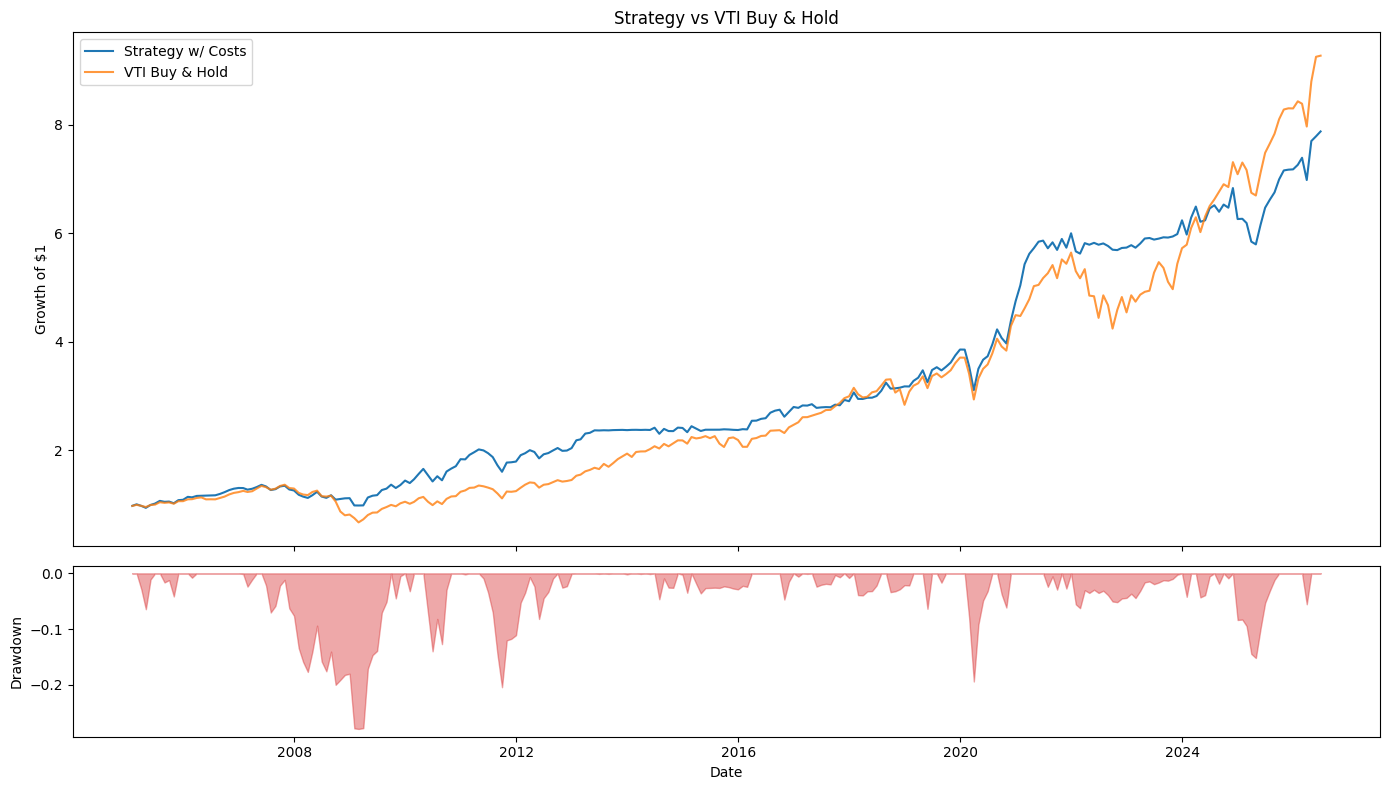

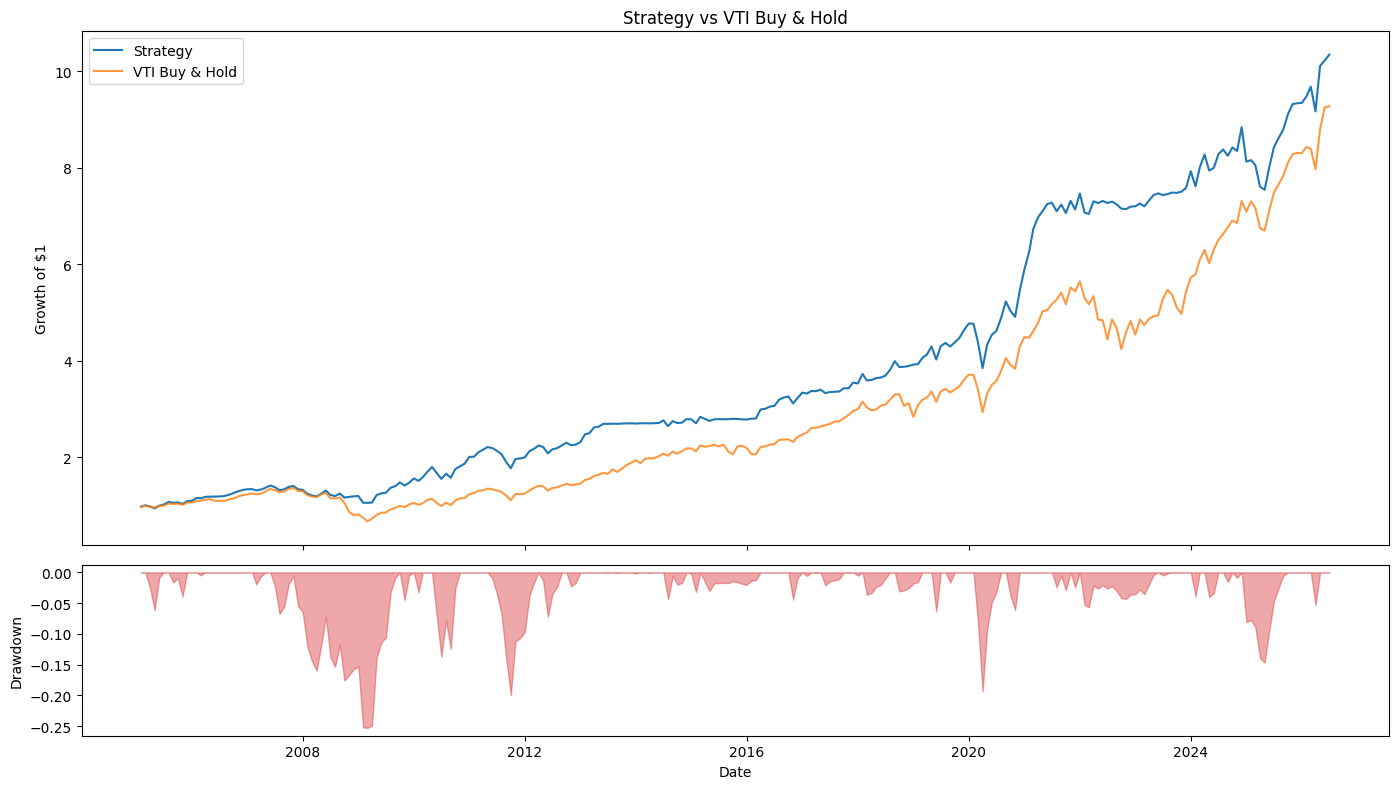

In [35]:
# With costs: what an investor paying fees and slippage would have experienced.
fig_costs = result.plot(use_costs=True)

# No costs: the closer approximation for a commission-free retail trader
# trading liquid ETFs today.
fig_no_cost = result.plot(use_costs=False)

The two charts tell the same story with one instructive difference at the finish line.

In both versions, the strategy's advantage is built in the slow bear markets and held thereafter. Through 2008 and into early 2009, VTI collapses while the strategy stays nearly flat, opening a lead that persists for years afterward. The drawdown panels make the protection vivid: VTI's worst trough reaches roughly −51% in the GFC, while the strategy's deepest drawdown is around −25%, and across the whole sample the strategy's red areas are consistently shallower and shorter than the benchmark's. The 2011 and 2022 declines show the same pattern, the strategy sidestepping the worst of each orderly drawdown. The 2020 COVID drop, by contrast, appears on both the strategy and VTI lines at similar depth, the visual confirmation of the V-shaped event we established the canary cannot avoid.

The difference between the two charts is the cost of turnover, and it shows up most at the end. The frictionless strategy compounds to about 10.3 times the starting capital, comfortably ahead of VTI's 9.3. Once conservative fees and slippage are charged on every rebalance, the strategy ends near 7.9, and VTI's buy-and-hold actually nudges ahead of it in final wealth. This is the same message as the slightly negative information ratio, seen on the curve: with full costs applied, the strategy does not win on raw ending wealth, it wins on the smoothness of the path taken to get there. For the commission-free retail trader, however, the relevant picture is the second chart, where the strategy leads on both wealth and risk, which is the case for trading it that the previous section laid out.

## 6.0 What does the canary actually contribute? Stripping it out

Section 3 evaluated the canary as a pure signal and concluded its value is real but lumpy, concentrated in slow bear markets. The backtest then confirmed the strategy protects capital. Neither, on its own, proves the protection came from the canary rather than from the momentum rotation among the three equity segments. To isolate the canary's contribution we do the cleanest test available: build the identical strategy with the canary removed, and compare.

The no-canary version keeps everything except the regime gate. It still ranks SPY, MDY, and IJR by their 13612 momentum every month and holds the strongest one, but it never retreats to SHY; it is always fully invested in equities. The only difference between the two strategies is whether the canary is allowed to pull the portfolio out of the market. So any difference in drawdown between them is the canary's doing, and nothing else. This mirrors the knockout approach used elsewhere in the chapter: remove one component, hold the rest fixed, and measure what changed.

In [36]:
# No-canary variant: always hold the strongest equity segment, never SHY.
# Identical selection logic, with the regime gate removed.
weights_nocanary = pd.DataFrame(
    0.0, index=composite_momentum.index, columns=WEIGHT_TICKERS
)

for date in weights_nocanary.index:
    scores = composite_momentum.loc[date, OFFENSIVE_TICKERS]
    # Warmup or incomplete equity scores: drop the row.
    if scores.isna().any():
        weights_nocanary.loc[date] = np.nan
        continue
    # Always fully invested in the strongest segment; SHY never used.
    weights_nocanary.loc[date, scores.idxmax()] = 1.0

weights_nocanary = weights_nocanary.dropna()
assert (weights_nocanary.sum(axis=1).round(10) == 1.0).all(), 'Weights do not sum to 1!'

holdings_nc = weights_nocanary.idxmax(axis=1)
print(f'No-canary weights shape: {weights_nocanary.shape}')
print(f'Months held in each instrument:')
print(holdings_nc.value_counts())

# Write its own sparse file and run it through the same harness.
NOCANARY_FILE = 'haa_mktcap_rotation_nocanary_weights.csv'
weights_nocanary.index.name = 'date'
weights_nocanary.to_csv(NOCANARY_FILE)
print(f'\nWrote no-canary weights to: {NOCANARY_FILE}')

No-canary weights shape: (258, 4)
Months held in each instrument:
SPY    115
IJR     80
MDY     63
Name: count, dtype: int64

Wrote no-canary weights to: haa_mktcap_rotation_nocanary_weights.csv


We run the no-canary weights through the same harness, with the same benchmark and the same cost assumptions, then place its metrics beside the full strategy's so the two are directly comparable.

In [37]:
# Backtest the no-canary variant identically.
result_nocanary = run_backtest(
    NOCANARY_FILE,
    benchmark=BENCHMARK_TICKER,
    fees=0.0010,
    slippage=0.0005,
    init_cash=10_000,
    periods_per_year=12,
    verbose=False,           # suppress the per-run table; we build our own
    prices=bt_prices,
    bench_prices=bm_prices,
)

# Put the two strategies side by side, using the with-costs column for each.
comparison = pd.DataFrame({
    'With canary':    result.metrics['Strategy w/ Costs'],
    'No canary':      result_nocanary.metrics['Strategy w/ Costs'],
    'VTI Buy & Hold': result.metrics['VTI Buy & Hold'],
})

print('Full strategy vs no-canary variant (all with costs applied):')
print(comparison.to_string())

Full strategy vs no-canary variant (all with costs applied):
                         With canary No canary VTI Buy & Hold
Total Return                 687.80%   446.83%        827.47%
Ann. Return (CAGR)            10.08%     8.22%         10.92%
Ann. Volatility               13.19%    16.51%         15.36%
Downside Deviation             7.91%    10.94%         10.08%
Max Drawdown                 -27.92%   -54.56%        -50.84%
Max DD Duration (months)          27        46             52
Ulcer Index                    6.370    12.833         11.640
Sharpe Ratio                   0.764     0.498          0.711
Sortino Ratio                  1.274     0.752          1.083
Calmar Ratio                   0.361     0.151          0.215
Ulcer Performance Index        1.582     0.641          0.938
Win Rate (monthly)             64.7%     62.8%          66.7%
Profit Factor                   1.92      1.51           1.76
Avg Win/Loss                    1.04      0.90           0.88
Informati

This comparison settles the question the whole notebook has been circling, and the answer is emphatic: the canary is the strategy. Removing it, while keeping the momentum rotation among the three equity segments completely intact, makes the strategy worse on nearly every measure that matters.

Look first at what we expected to find, the drawdown protection. The full strategy's worst loss was −27.9%; strip out the canary and it balloons to −54.6%, slightly worse even than VTI's −50.8%. Without the regime gate, the portfolio rides every equity decline straight to the bottom, and the Ulcer Index doubles from 6.4 to 12.8. Every dollar of drawdown protection the strategy provides comes from the canary, exactly as the signal analysis predicted. The momentum rotation among large, mid, and small caps offers no defense at all on its own, because all three segments fall together in a crisis.

Now the result I did not promise you in advance, and the one that makes this strategy genuinely compelling. Removing the canary did not just raise risk, it lowered return. The no-canary variant compounds at 8.22% against the full strategy's 10.08%, a CAGR loss of nearly two full points. This is the opposite of the usual risk-return trade-off, where defense costs you growth. Here the defense pays for itself, because the months the canary pulls you out of equities are, on balance, months you were better off avoiding, and sidestepping the deepest drawdowns means you compound from a higher base when the recovery comes. Avoiding a −50% loss is worth more than capturing the volatile months around it, and over 21 years that edge shows up directly in the growth rate.

The risk-adjusted measures put an exclamation point on it. The canary lifts the Sharpe ratio from 0.50 to 0.76, the Sortino from 0.75 to 1.27, and the Calmar from 0.15 to 0.36. The no-canary variant is worse than simple VTI buy-and-hold on Sharpe, drawdown, and Ulcer Index, meaning the equity rotation by itself actively underperforms just holding the total market. It is the canary, and only the canary, that turns a mediocre rotation scheme into a strategy worth running. That is the clearest possible vindication of building, and separately testing, a regime signal: the component we put on trial in section 3 turns out to carry the entire result.

## 7.0 Visualizing the canary in action

Three figures make the canary's behavior concrete. The first is the confusion matrix from the isolation test, drawn as a grayscale heatmap so the four outcome cells can be read at a glance. The second turns the same four cells into a payoff chart, showing the average return in each and making the tail-protection asymmetry visible. The third is a timeline of what the strategy held each month, with the defensive stretches shaded, so you can see the canary stepping aside during the slow bear markets and staying invested through the bull runs.

All three are built to survive black-and-white printing: no figure relies on color to carry meaning, using grayscale fills, distinct hatch patterns, and direct labels instead.

### 7.1 The confusion matrix as a heatmap

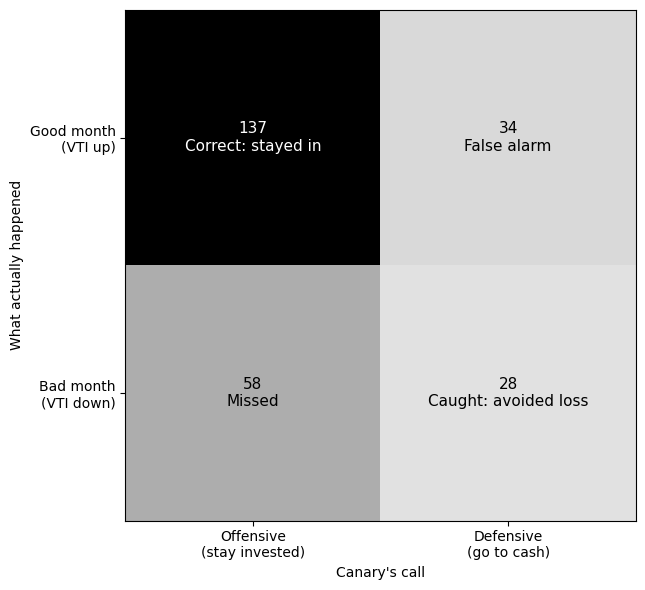

In [38]:
# Figure 13.x: confusion matrix of the canary's monthly calls.
# Grayscale (Greys) so it prints in black and white.
fig, ax = plt.subplots(figsize=(7, 6))

cm_display = confusion_matrix(eval_df['actual_bad'], eval_df['pred_defensive'])
im = ax.imshow(cm_display, cmap='Greys', vmin=0, vmax=cm_display.max())

# Tick labels.
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Offensive\n(stay invested)', 'Defensive\n(go to cash)'])
ax.set_yticklabels(['Good month\n(VTI up)', 'Bad month\n(VTI down)'])
ax.set_xlabel("Canary's call")
ax.set_ylabel('What actually happened')

# Annotate each cell with its count and plain-language role.
roles = [['Correct: stayed in', 'False alarm'],
         ['Missed', 'Caught: avoided loss']]
for i in range(2):
    for j in range(2):
        count = cm_display[i, j]
        # Choose readable text color against the grayscale fill.
        shade = count / cm_display.max()
        txt_color = 'white' if shade > 0.5 else 'black'
        ax.text(j, i, f'{count}\n{roles[i][j]}',
                ha='center', va='center', color=txt_color, fontsize=11)

# ax.set_title('Figure 13.5: The canary as a monthly classifier')
plt.tight_layout()
plt.show()

### 7.2 The payoff behind each call

The confusion matrix counts the four outcomes; this figure weighs them. For each of the same four cells we plot the average next-month VTI return, which turns the classifier into a payoff chart. The bar heights show what was at stake in each kind of call: the depth of the losses caught and missed, and the size of the upside given up on false alarms. This is the picture that resolves the paradox of a poor classifier producing a strong strategy, because it shows the losses the canary avoids are deeper than the gains it forgoes.

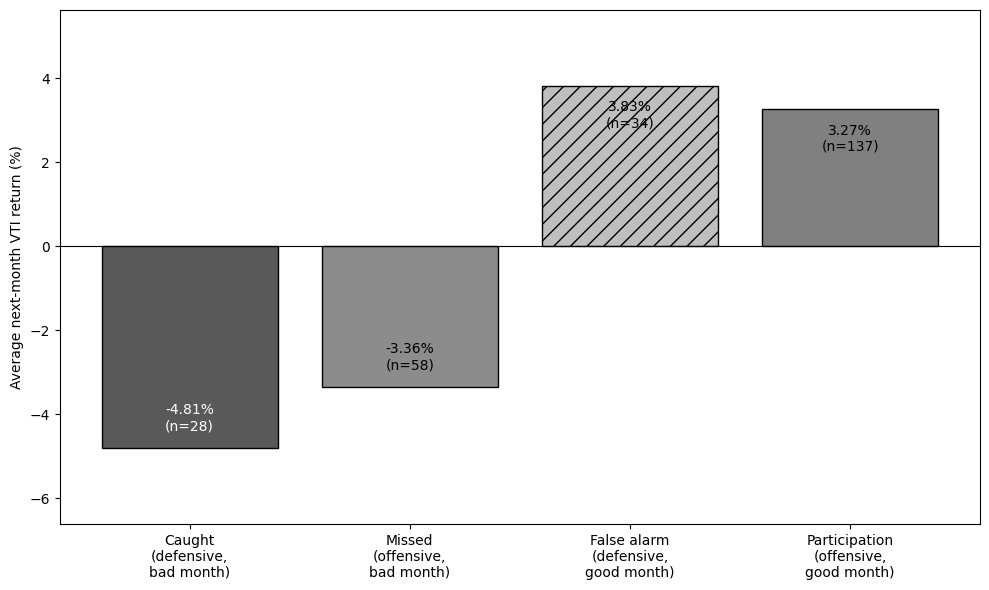

In [39]:
# Figure 13.x: average next-month VTI return in each confusion-matrix cell.
# Grayscale fills + hatch patterns so the bars are distinct in print.
labels = ['Caught\n(defensive,\nbad month)',
          'Missed\n(offensive,\nbad month)',
          'False alarm\n(defensive,\ngood month)',
          'Participation\n(offensive,\ngood month)']
values = [
    cells['Defensive + bad month (saves)'][1],
    cells['Offensive + bad month (misses)'][1],
    cells['Defensive + good month (false alarm)'][1],
    cells['Offensive + good month (participation)'][1],
]
counts = [
    cells['Defensive + bad month (saves)'][0],
    cells['Offensive + bad month (misses)'][0],
    cells['Defensive + good month (false alarm)'][0],
    cells['Offensive + good month (participation)'][0],
]

shades = ['0.35', '0.55', '0.75', '0.5']
hatches = ['', '', '//', '']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, [v * 100 for v in values],
              color=shades, edgecolor='black', hatch=hatches)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Average next-month VTI return (%)')
# ax.set_title('Figure 13.x: What each canary call was worth')

# Headroom so labels never collide with the title or the x-axis.
ymax = max(v * 100 for v in values)
ymin = min(v * 100 for v in values)
ax.set_ylim(ymin - 1.8, ymax + 1.8)

# Place each value label just INSIDE the bar, toward zero, so it never
# crosses an axis boundary.
for bar, v, n in zip(bars, values, counts):
    height = v * 100
    if height >= 0:
        y = height - 0.35
        va = 'top'
    else:
        y = height + 0.35
        va = 'bottom'
    txt_color = 'white' if bar.get_facecolor()[0] < 0.5 else 'black'
    ax.text(bar.get_x() + bar.get_width() / 2, y,
            f'{v:.2%}\n(n={n})', ha='center', va=va,
            fontsize=10, color=txt_color)

plt.tight_layout()
plt.show()

### 7.3 A timeline of what the strategy held

The final figure shows the strategy's monthly holding across the whole sample, with the defensive (SHY) stretches shaded so the canary's interventions stand out. Reading it against the crises we studied, the defensive bands should cluster around the slow bear markets the canary handles well, 2008 and 2022, and be sparse or absent during the long bull runs and the fast 2020 reversal. This puts the entire behavior of the strategy on one timeline, connecting the signal analysis to the actual allocation decisions.

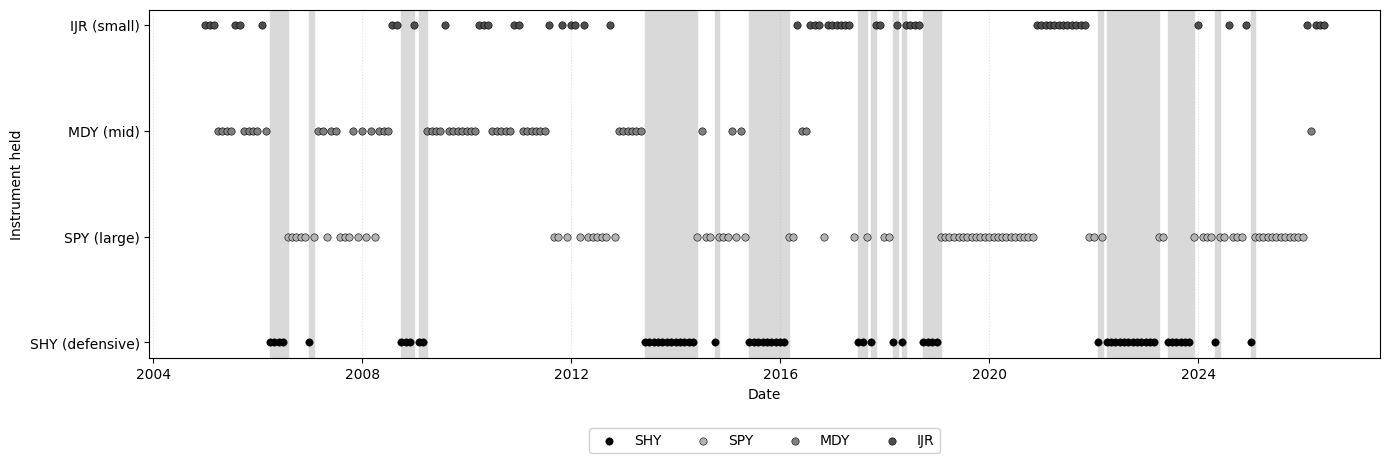

In [40]:
# Figure 13.x: monthly holding over time, with defensive months shaded.
# Each instrument gets a distinct grayscale level; SHY months also get a
# shaded band so the defensive stretches are obvious in print.
instrument_levels = {'SHY': 0, 'SPY': 1, 'MDY': 2, 'IJR': 3}
instrument_shades = {'SHY': '0.0', 'SPY': '0.7', 'MDY': '0.5', 'IJR': '0.3'}

holding_level = holdings.map(instrument_levels)

fig, ax = plt.subplots(figsize=(14, 5))

# Plot each month as a marker at its instrument's level, shaded by instrument.
for inst, lvl in instrument_levels.items():
    mask = holdings == inst
    ax.scatter(holdings.index[mask], holding_level[mask],
               color=instrument_shades[inst], edgecolor='black',
               linewidth=0.4, s=28, label=inst, zorder=3)

# Shade the defensive (SHY) months as vertical bands.
defensive_dates = holdings.index[holdings == 'SHY']
for d in defensive_dates:
    ax.axvspan(d, d + pd.Timedelta(days=31), color='0.85', zorder=0)

ax.set_yticks(list(instrument_levels.values()))
ax.set_yticklabels(['SHY (defensive)', 'SPY (large)', 'MDY (mid)', 'IJR (small)'])
ax.set_ylabel('Instrument held')
ax.set_xlabel('Date')
# ax.set_title('Figure 13.6: Monthly holding and defensive periods')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4, framealpha=0.9)
ax.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 8.0 Summary

This notebook built a market-cap rotation strategy, but the rotation was never the point. The point was the canary, and the discipline of testing a regime signal on its own before trusting it with capital. We learned to treat a regime filter as what it really is, a binary classifier, and to evaluate it the way a classifier deserves: a confusion matrix, a classification report, the conditional payoff of each kind of call, an event study across every major crisis, and a persistence check for whipsaw. The conventional classifier metrics were unimpressive, with precision and recall both modest and an accuracy that trailed simply staying invested, and yet the signal carried the entire strategy. The resolution was asymmetry: those metrics weight every month equally, but the months are not equal, and the canary is right when it counts, sidestepping the deep, slow drawdowns while giving back only modest upside on its false alarms. The knockout test sealed the argument, because removing the canary while keeping everything else lifted the maximum drawdown from −28% to −55% and lowered the return at the same time. The defensive overlay paid for itself.

I hope you now see why I included this strategy. Regime-switching strategies are deeply attractive, because we all like to think we know how to time the markets and that when we do, we make a lot of money by avoiding the drawdowns. Sadly, most people are overconfident, and humans tend to be very bad at timing markets. A good set of rules can accomplish what discretion cannot. The rules will not be right 100% of the time, but as you have just learned, this was never about accuracy; it is about being right when it counts.

One more point about regime-switching strategies that use a signal overlay: normally you sacrifice some upside to gain the downside protection, and that is a fair trade. Ultimately it is the return earned for the amount of risk taken that matters. We would all love a strategy that returns 40% a year at low risk, and most of us would happily take 40% a year at high risk as long as the Sharpe ratio is close to 1, but those are not easy to build. Not every strategy in your portfolio should be a grand-slam-seeking risk machine.

I personally love strategies like this one because:

- The Sharpe ratio is over 1 before fees, earning roughly 12% a year with 10% to 13% volatility. That is an excellent risk-reward ratio, better than almost every balanced fund available.
- The downside protection works. Not all of the time, but it works when we need it most, and 2022 is a great example.
- It is evaluated monthly and holds a single position at a time, which makes it very easy to implement.

This strategy is a core one in my portfolio.

In the next section, we move from a strategy whose edge comes from a regime overlay to one whose edge comes from a different source entirely, continuing to build the toolkit of approaches a systematic trader can draw on.